In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
import h5py
from utils import TwoDimParVar

In [2]:
nints = 10
rangespsi0 = np.linspace(-3.5,-1.3,nints)
rangeslogm0 = np.linspace(10.5, 12.7, nints)
rangesmu = np.linspace(7.5,9.7, nints)
rangeseps = np.linspace(0, 1, nints)
rangestau = np.linspace(0.1, 11.0, nints)
rangesgamma = np.linspace(-1.5,0, nints)
psi0 = ('psi0',rangespsi0)
m0 = ('m0',rangeslogm0)
mass_norm = ('mass_norm',rangesmu)
scatter = ('scatter', rangeseps)
tau = ('tau', rangestau)
gamma_inner = ('gamma_inner',rangesgamma)

ranges = dict([psi0, m0, mass_norm, scatter, tau, gamma_inner])

In [4]:
#Create a tuple with all possible parameter combinations
subranges = []
for i,v in enumerate(ranges):
    for j,w in enumerate(ranges):
        if i > j:
            subranges.append(dict([(w,list(ranges.values())[j]),(v,list(ranges.values())[i])]))

In [5]:
#For each of these combinations, initialize an object
#Set load = True only if I want to re-initialize the whole set
#At some point add warning about shape, num_reals etc or try to import them from outside when set differently.
t = [TwoDimParVar(i,bound_type = 'Lumdist', model='all_sky',full_analysis=False) for i in subranges]

In [5]:
#%%time
#cdf = t[0].get_Strain_probs() #approx 13 minutes to apply for a set of param pairs-> 8 seconds per hc_ss calculation

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [45:13<00:00, 67.83s/it]

CPU times: total: 41min 48s
Wall time: 45min 13s


In [15]:
#np.savez(f'hc_CDF/pars_{list(t[0].par_ranges.keys())}_dists', cdf)

In [7]:
a = [i.getAcceptedVals()[2] for i in t]

In [8]:
l = [v.CalculateLikelihood(a[i]) for i,v in enumerate(t)]

In [9]:
mean_like_grid_hc = np.mean(l)
mean_like_grid_hc

0.7068466666666666

In [56]:
print(mean_like_grid_Lumdist_all_sky)
print(mean_like_grid_Lumdist_r_eff)
print(mean_like_grid_hc)

0.7452666666666667
0.7070200000000001
0.6294266666666667


KeyboardInterrupt: 

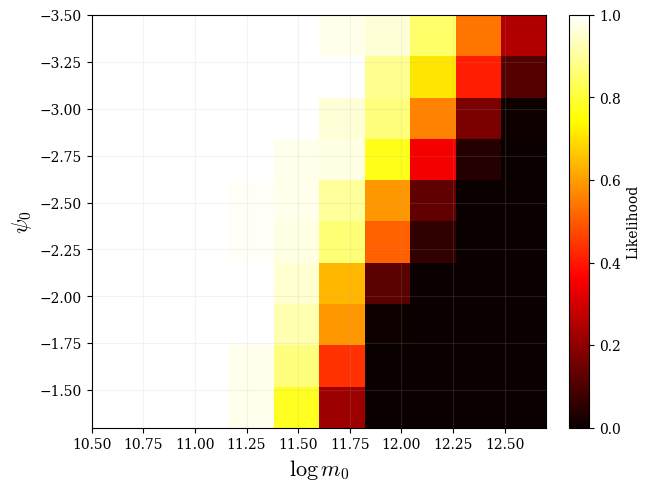

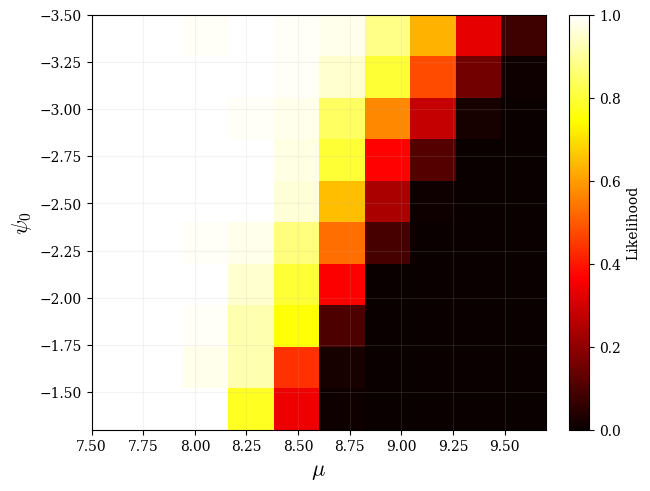

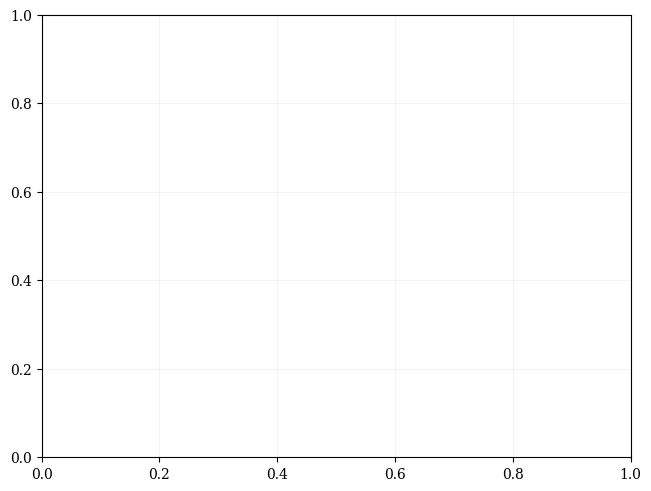

In [6]:
[i.getFig() for i in t]